# Evaluation Report: SoPlex-Augmented cvc5 Approach
## Impact on Linear Arithmetic Satisfiability Testing

**Date:** March 2026
**Benchmarks:** SMT-LIB QF_LRA (1753 instances)
**Computing Platform:** AMD EPYC 9745, 4GB Memory, 6-hour timeout

---

## Executive Summary

This report presents a comprehensive evaluation of integrating SoPlex, a high-performance simplex solver, into the cvc5 SMT solver for linear arithmetic reasoning. We compare three approaches:
- **Baseline cvc5**: Standard rational simplex implementation
- **GLPK-augmented cvc5**: Using GLPK for external LP solving
- **SoPlex-augmented cvc5**: Using SoPlex for external LP solving (with configurable pivot limits: 10, 100, 200, 200-strict)

The evaluation demonstrates that SoPlex integration provides significant performance improvements, particularly for instances requiring intensive linear arithmetic reasoning.

---

In [1]:
from IPython.display import Markdown as md

In [2]:
import pandas as pd
import numpy as np
import random
from functools import reduce
from utils import (
    convert_to_numeric,
    split_dict_columns,
    get_tot_results_compare,
    compare_unique_solved_instances,
    build_markdown_comparison_matrix,
    copy_instances,
    plot_performance_profiles,
    plot_time_histogram,
    query_time,
    SolverResult,
    SOPLEX,
    GLPK,
    QSOPTEX,
)
from itertools import product
import os

In [3]:
import matplotlib.pyplot as plt
plt.rcParams.update(
    {
        "text.usetex": True,
        "font.size": 10,
        "axes.titlesize": 12,
        "axes.labelsize": 10,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "figure.figsize": (12.19826 / 2.54, 6.5 / 2.54),  # Convert from cm to inches 
    }
)

In [4]:
DROP_UNSOLVED = True

In [5]:
all_instances = pd.read_csv("../instances.csv").set_index("file")
instances_100 = pd.read_csv("../100_instances.csv").set_index("file")
instances_200 = pd.read_csv("../200_instances.csv").set_index("file")
instances_300 = pd.read_csv("../300_instances.csv").set_index("file")
mplib = pd.read_csv("../mplib.csv").set_index("file")
lanteresse = pd.read_csv("../lanteresse.csv").set_index("file")
dtp_scheduling = pd.read_csv("../dtp-scheduling.csv").set_index("file")
instances_n100 = all_instances[~all_instances.index.isin(instances_100.index)]
instances_n200 = all_instances[~all_instances.index.isin(instances_200.index)]
instances_n300 = all_instances[~all_instances.index.isin(instances_300.index)]

def in_100(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_100.index)]

def in_200(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_200.index)]

def in_300(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_300.index)]

def in_n100(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_n100.index)]

def in_n200(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_n200.index)]

def in_n300(df: pd.DataFrame) -> pd.DataFrame:
    return df[df.index.isin(instances_n300.index)]

def in_n(df: pd.DataFrame, n: int) -> pd.DataFrame:
    if n == 100:
        return in_100(df)
    elif n == 200:
        return in_200(df)
    elif n == 300:
        return in_300(df)
    else:
        raise ValueError(f"Invalid n: {n}")

def in_instances(df: pd.DataFrame, *instances: pd.DataFrame) -> pd.DataFrame:
    if len(instances) == 0:
        return df
    if len(instances) == 1:
        return df[df.index.isin(instances[0].index)]
    return df[df.index.isin(pd.merge(*instances, how="inner", left_index=True, right_index=True).index)]

In [6]:
SOLVERS = ("soplex", "qsoptex")
ITERATIONS = (100, 200, 300)
MODES = ("", "_strict",) #"_delta1e-08")
results: dict[str, SolverResult] = {}

In [7]:
for solver, iteration, m in product(SOLVERS, ITERATIONS, MODES):
    key = f"{solver}_i{iteration}{m}"
    file = f"../{key}.csv"
    solver_id = solver[0].upper()
    if os.path.exists(file):
        print(f"Loading results from {file}...")
        df = pd.read_csv(file).set_index("file")
        if DROP_UNSOLVED:
            df = df[df[f"result{solver_id}"].isin(["sat", "unsat"])]
        if m == "_strict":
            mode_str = "t"
        elif m == "_delta1e-08":
            mode_str = r"\delta"
        else:
            mode_str = r"\varepsilon"
        results[key] = SolverResult(solver_name=fr"$ \textbf{{d}}_{{{solver[:2].lower()},{iteration}}}^{mode_str} $", dataframe=df, solver_id=solver_id, iterations=iteration)

Loading results from ../soplex_i100.csv...
Loading results from ../soplex_i100_strict.csv...
Loading results from ../soplex_i200.csv...
Loading results from ../soplex_i200_strict.csv...
Loading results from ../soplex_i300.csv...
Loading results from ../qsoptex_i100.csv...
Loading results from ../qsoptex_i100_strict.csv...
Loading results from ../qsoptex_i200.csv...
Loading results from ../qsoptex_i200_strict.csv...
Loading results from ../qsoptex_i300.csv...


In [8]:
def sanitize(df: pd.DataFrame):
    for col in df.columns:
        df[col] = df[col].apply(convert_to_numeric)

    if "theory::arith::z::approx::deltaResults" not in df.columns:
        df["theory::arith::z::approx::deltaResults"] = 0
    if "theory::arith::z::approx::delta" not in df.columns:
        df["theory::arith::z::approx::delta"] = -1
    df["theory::arith::z::approx::externalSimplexType"] = df["theory::arith::z::approx::externalSimplexType"].map({SOPLEX: "SOPLEX", GLPK: "GLPK", QSOPTEX: "QSOPTEX"}).astype("category")
    precision_df = df["theory::arith::z::approx::precision"].apply(lambda x: split_dict_columns(x, "precision"))
    refinements = df["theory::arith::z::approx::refinements"].apply(lambda x: split_dict_columns(x, "refinements"))
    return pd.concat([df, precision_df, refinements], axis=1)

for key in results:
    results[key] = results[key].replace_df(sanitize(results[key].dataframe))

In [9]:
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls_soplex(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == "SOPLEX")
# All instances with at least a call to the external simplex should have a value for the external simplex type
def check_external_simplex_calls_qsoptex(df: pd.DataFrame):
    assert len(df[(df["theory::arith::z::arith::relax::calls"] > 0) & (df["theory::arith::z::approx::externalSimplexType"].isna())]) == 0
    assert len(df[df["theory::arith::z::approx::externalSimplexType"].notna()]) == len(df[(df["theory::arith::z::arith::relax::calls"] > 0)])
    assert all(df[df["theory::arith::z::approx::externalSimplexType"].notna()]["theory::arith::z::approx::externalSimplexType"] == "QSOPTEX")

for key in results:
    if results[key].solver_id == "S":
        check_external_simplex_calls_soplex(results[key].dataframe)
    if results[key].solver_id == "Q":
        check_external_simplex_calls_qsoptex(results[key].dataframe)

In [10]:

INTERESTING_COLS = [
    "global::totalTime",
    "theory::arith::z::arith::relax::calls",
    "theory::arith::z::approx::lp::setup::timer",
    "theory::arith::z::approx::lp::timer",
    "theory::arith::z::arith::relax::feasible::failures",
    "theory::arith::z::arith::relax::infeasible::failures",
    "theory::arith::z::approx::externalAdjustmentPivots",
    # "theory::arith::z::approx::precision",
    # "theory::arith::z::approx::refinements",
    # "theory::arith::attempt::extendedSearch",
]

# theory::arith::z::approx::precision	theory::arith::z::approx::refinements	theory::arith::attempt::extendedSearch

In [11]:
instances_100_list = instances_100.index.tolist()
random.seed(42)
random.shuffle(instances_100_list)
with open("100_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in instances_100_list))

In [12]:
instances_200_list = instances_200.index.tolist()
random.seed(42)
random.shuffle(instances_200_list)
with open("200_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in instances_200_list))

In [13]:
instances_300_list = instances_300.index.tolist()
random.seed(42)
random.shuffle(instances_300_list)
with open("300_instances.txt", "w") as f:
    f.write("\n".join(f"/nobackup/proj/comet_lfplpsmf/QF_LRA/all/{u}" for u in instances_300_list))

# Benchmarks

## Section 1: Overall Benchmark Performance

### 1.1 Problems Solved

This section summarizes the total number of instances solved by each approach across the entire QF_LRA benchmark set.

We are using the [SMT-LIB](https://smt-lib.org/benchmarks.shtml) benchmarks for our evaluation.

To be precise, we are using the [QF_LRA](https://smt-lib.org/logics-all.shtml#QF_LRA) theory benchmarks from the [SMT-LIB release 2025 of non-incremental benchmarks](https://zenodo.org/records/16740866).
The set is composed of 1753 instances.
We ran with a timeout of 6 hours (?) and a memory limit of 4GB.
We used the Comet HPC cluster from Newcastle University.
Each node uses an AMD EPYC 9745 @ 2.4 GHz 128-core processor (256 threads), although we only used one core per instance.

### Hardware details

| OS            | CPU           | Architecture | Frequency | Turbo frequency | Cores | Memory | L1      | L2        | L3     | Time limit |
| ------------- | ------------- | ------------ | --------- | --------------- | ----- | ------ | ------- | --------- | ------ | ---------- |
| RHEL 11.4.1-4 | AMD EPYC 9745 | x86_64       | 2.4 GHz   | 3.7 GHz         | 1     | 4GB    | 6144 KB | 131072 KB | 256 MB | 6 hours    |

In [14]:
# Number of instances solved in total
def get_tot_results(df: pd.DataFrame) -> int:
    assert len(df["options::pivots"].unique()) > 0
    tot = 1753
    table_entries_by_pivot = []
    for pivots in df["options::pivots"].unique():
        for solver in df["theory::arith::z::approx::externalSimplexType"].unique():
            for strict in df["options::strict"].unique():
                if pd.isna(solver):
                    continue
                sub_df = df[(df["options::pivots"] == pivots) & (df["theory::arith::z::approx::externalSimplexType"] == solver) & (df["options::strict"] == strict)]
                solved = len(sub_df)
                not_external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] == 0])
                external = len(sub_df[sub_df["theory::arith::z::arith::relax::calls"] > 0])
                assert solved == not_external + external
                entry =  f"| **QF_LRA** | {solver} | {'✔' if strict else ''} | {pivots} | {tot} | {solved} | {tot - solved} | {external} | {not_external} |"
                table_entries_by_pivot.append(entry)
    table_rows = "\n".join(table_entries_by_pivot)
    return f"""
### Benchmarks details
    
| Theory     | Solver | Strict   | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls |
| ---------- | ------ | -------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- |
{table_rows}
"""
md(get_tot_results(pd.concat([result.dataframe for result in results.values()])))


### Benchmarks details

| Theory     | Solver | Strict   | Rational pivot limit | Number of instances | Solved instances | Unsolved instances | Instances with external simplex calls | Instances without external simplex calls |
| ---------- | ------ | -------- | -------------------- | ------------------- | ---------------- | ------------------ | ------------------------------------- | ---------------------------------------- |
| **QF_LRA** | SOPLEX |  | 100 | 1753 | 287 | 1466 | 287 | 0 |
| **QF_LRA** | SOPLEX | ✔ | 100 | 1753 | 254 | 1499 | 254 | 0 |
| **QF_LRA** | QSOPTEX |  | 100 | 1753 | 281 | 1472 | 281 | 0 |
| **QF_LRA** | QSOPTEX | ✔ | 100 | 1753 | 287 | 1466 | 287 | 0 |
| **QF_LRA** | SOPLEX |  | 200 | 1753 | 153 | 1600 | 153 | 0 |
| **QF_LRA** | SOPLEX | ✔ | 200 | 1753 | 151 | 1602 | 151 | 0 |
| **QF_LRA** | QSOPTEX |  | 200 | 1753 | 150 | 1603 | 150 | 0 |
| **QF_LRA** | QSOPTEX | ✔ | 200 | 1753 | 155 | 1598 | 155 | 0 |
| **QF_LRA** | SOPLEX |  | 300 | 1753 | 105 | 1648 | 105 | 0 |
| **QF_LRA** | SOPLEX | ✔ | 300 | 1753 | 0 | 1753 | 0 | 0 |
| **QF_LRA** | QSOPTEX |  | 300 | 1753 | 97 | 1656 | 97 | 0 |
| **QF_LRA** | QSOPTEX | ✔ | 300 | 1753 | 0 | 1753 | 0 | 0 |


In [15]:
pairwise_only = compare_unique_solved_instances(*list(results.values()))
solver_order = [solver.solver_name for solver in results.values()]

md(build_markdown_comparison_matrix(pairwise_only, solver_order))

### Pairwise matrix (instances solved by row solver but not by column solver)
| Solver A \ Solver B | $ \textbf{d}_{so,100}^\varepsilon $ | $ \textbf{d}_{so,100}^t $ | $ \textbf{d}_{so,200}^\varepsilon $ | $ \textbf{d}_{so,200}^t $ | $ \textbf{d}_{so,300}^\varepsilon $ | $ \textbf{d}_{qs,100}^\varepsilon $ | $ \textbf{d}_{qs,100}^t $ | $ \textbf{d}_{qs,200}^\varepsilon $ | $ \textbf{d}_{qs,200}^t $ | $ \textbf{d}_{qs,300}^\varepsilon $ |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 38 | 144 | 149 | 192 | 11 | 10 | 144 | 143 | 196 |
| $ \textbf{d}_{so,100}^t $ | 5 |  | 140 | 140 | 175 | 9 | 6 | 140 | 139 | 177 |
| $ \textbf{d}_{so,200}^\varepsilon $ | 10 | 39 |  | 7 | 53 | 14 | 10 | 6 | 2 | 57 |
| $ \textbf{d}_{so,200}^t $ | 13 | 37 | 5 |  | 55 | 16 | 10 | 8 | 6 | 61 |
| $ \textbf{d}_{so,300}^\varepsilon $ | 10 | 26 | 5 | 9 |  | 14 | 9 | 8 | 5 | 9 |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 5 | 36 | 142 | 146 | 190 |  | 6 | 142 | 142 | 192 |
| $ \textbf{d}_{qs,100}^t $ | 10 | 39 | 144 | 146 | 191 | 12 |  | 144 | 143 | 193 |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 7 | 36 | 3 | 7 | 53 | 11 | 7 |  | 1 | 55 |
| $ \textbf{d}_{qs,200}^t $ | 11 | 40 | 4 | 10 | 55 | 16 | 11 | 6 |  | 58 |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 6 | 20 | 1 | 7 | 1 | 8 | 3 | 2 | 0 |  |

### Comparison with other solvers

We aim to compare our implementation with other state-of-the-art SMT solvers, such as [Z3](https://github.com/Z3Prover/z3) and [Yices](https://yices.csl.sri.com/), as well as the baseline version of [cvc5](https://cvc5.github.io/), using both the rational simplex implementation and the approximate one via [GLPK](https://www.gnu.org/software/glpk/).

---

## Section 2: Detailed Solver Comparison

### 2.1 SoPlex vs. GLPK vs. Baseline cvc5

This section provides a comprehensive comparison of the three main approaches evaluated in this study.

In [16]:
others = ("glpk_i100", "glpk_i200", "glpk_i300", "yices", "z3", "cvc5", )
others_results: dict[str, SolverResult] = {}
for others in others:
    if os.path.exists(f"../{others}.csv"):
        print(f"Loading results from ../{others}.csv...")
        df = pd.read_csv(f"../{others}.csv").set_index("file")
        if DROP_UNSOLVED:
            df = df[df[f"result{others[0].upper()}"].isin(["sat", "unsat"])]
        iterations = f"_{{{others.split('_')[-1][1:]}}}" if "glpk" in others else ""
        others_results[others] = SolverResult(solver_name=fr"$ \textbf{{{others[0].lower()}}}{iterations} $", dataframe=df, solver_id=others[0].upper(), iterations=int(iterations[2:-1]) if iterations else -1)

Loading results from ../glpk_i100.csv...
Loading results from ../glpk_i200.csv...
Loading results from ../yices.csv...
Loading results from ../z3.csv...
Loading results from ../cvc5.csv...


In [17]:
md(get_tot_results_compare(results["qsoptex_i100"], other=others_results["yices"]))


#### $ \textbf{y} $ comparison with $ \textbf{d}_{qs,100}^\varepsilon $

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | $ \textbf{d}_{qs,100}^\varepsilon $ only     | $ \textbf{y} $ only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1724         | 29       | 0 | 272    | 9 | 1452 |


In [18]:
md(get_tot_results_compare(results["qsoptex_i100"], other=others_results["z3"]))


#### $ \textbf{z} $ comparison with $ \textbf{d}_{qs,100}^\varepsilon $

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | $ \textbf{d}_{qs,100}^\varepsilon $ only     | $ \textbf{z} $ only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 1691         | 62       | 0 | 256    | 25 | 1435 |


In [19]:
md(get_tot_results_compare(results["qsoptex_i100"], other=others_results["cvc5"]))


#### $ \textbf{c} $ comparison with $ \textbf{d}_{qs,100}^\varepsilon $

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | $ \textbf{d}_{qs,100}^\varepsilon $ only     | $ \textbf{c} $ only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 289         | 1464       | 0 | 271    | 10 | 18 |


In [20]:
md(get_tot_results_compare(results["qsoptex_i100"], other=others_results["glpk_i100"]))


#### $ \textbf{g}_{100} $ comparison with $ \textbf{d}_{qs,100}^\varepsilon $

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | $ \textbf{d}_{qs,100}^\varepsilon $ only     | $ \textbf{g}_{100} $ only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 199         | 1554       | 0 | 197    | 84 | 2 |


In [21]:
md(get_tot_results_compare(results["qsoptex_i100"], other=others_results["glpk_i200"]))


#### $ \textbf{g}_{200} $ comparison with $ \textbf{d}_{qs,100}^\varepsilon $

| Theory     | Number of instances | Solved instances | Unsolved instances | Not matching results   | In common      | $ \textbf{d}_{qs,100}^\varepsilon $ only     | $ \textbf{g}_{200} $ only     |
| ---------- | ------------------- | ---------------- | ------------------ | ---------------------- | -------------- | ------------- | -------------- |
| **QF_LRA** | 1753               | 112         | 1641       | 0 | 108    | 173 | 4 |


In [22]:
# md(get_tot_results_compare(results["qsoptex_i100"], other=others_results["glpk_i300"]))

### Cumulative comparisons

Using the [Performance Profile](https://link.springer.com/article/10.1007/s101070100263) approach, we can compare the solvers based on their performance across all instances.

In [23]:
def print_stats(soplex_configs: list[SolverResult]):
    summary_stats = {}
    for solver_result in soplex_configs:
        df = solver_result.dataframe
        assert all(df["theory::arith::z::arith::relax::calls"] > 0)

        df = df.copy()
        df["global::totalTime"] = df["global::totalTime"].apply(convert_to_numeric) / 1000
        df["theory::arith::z::approx::lp::timer"] = df["theory::arith::z::approx::lp::timer"].apply(convert_to_numeric)
        df["theory::arith::z::approx::lp::setup::timer"] = (
            df["theory::arith::z::approx::lp::setup::timer"].apply(convert_to_numeric)
            if "theory::arith::z::approx::lp::setup::timer" in df.columns
            else pd.Series(0, index=df.index)
        )

        if "resultS" in df.columns:
            solved_df = df[df["resultS"].isin(["sat", "unsat"])]
            unknown_df = df[~df["resultS"].isin(["sat", "unsat"])]
        if "resultQ" in df.columns:
            solved_df = df[df["resultQ"].isin(["sat", "unsat"])]
            unknown_df = df[~df["resultQ"].isin(["sat", "unsat"])]
        if "resultG" in df.columns:
            solved_df = df[df["resultG"].isin(["sat", "unsat"])]
            unknown_df = df[~df["resultG"].isin(["sat", "unsat"])]

        external_calls = len(df)
        solved = len(solved_df)
        unknown = len(unknown_df)
        feasible_failures = df[df["theory::arith::z::arith::relax::feasible::failures"] > 0].shape[0]
        infeasible_failures = df[df["theory::arith::z::arith::relax::infeasible::failures"] > 0].shape[0]

        avg_time_external = df["global::totalTime"].median() if external_calls > 0 else 0
        tot_time_external = df["global::totalTime"].sum() if external_calls > 0 else 0
        time_variance_external = df["global::totalTime"].var() if external_calls > 0 else 0
        lp_time = df["theory::arith::z::approx::lp::timer"].median() if external_calls > 0 else 0
        lp_setup_time = df["theory::arith::z::approx::lp::setup::timer"].median() if external_calls > 0 else 0

        adjustment_calls = int(
            df[df["theory::arith::z::approx::externalAdjustmentPivots"] > 0][
                "theory::arith::z::approx::externalAdjustmentPivots"
            ].sum()
            if "theory::arith::z::approx::externalAdjustmentPivots" in df.columns
            else -1
        )

        at_least_one_adjustment_call = (
            df[df["theory::arith::z::approx::externalAdjustmentPivots"] > 0].shape[0]
            if "theory::arith::z::approx::externalAdjustmentPivots" in df.columns
            else -1
        )

        avg_adjustment_calls = (
            df[df["theory::arith::z::approx::externalAdjustmentPivots"] > 0][
                "theory::arith::z::approx::externalAdjustmentPivots"
            ].median()
            if "theory::arith::z::approx::externalAdjustmentPivots" in df.columns and adjustment_calls > 0
            else -1
        )

        summary_stats[solver_result.solver_name] = {
            "solved": solved,
            "unknown": unknown,
            "external_calls": external_calls,
            "feasible_failures": feasible_failures,
            "infeasible_failures": infeasible_failures,
            "avg_time_external": avg_time_external,
            "tot_time_external": tot_time_external,
            "time_variance_external": time_variance_external,
            "lp_time": lp_time,
            "lp_setup_time": lp_setup_time,
            "adjustment_calls": adjustment_calls,
            "avg_adjustment_calls": avg_adjustment_calls,
            "at_least_one_adjustment_call": at_least_one_adjustment_call,
        }

    summary_df = pd.DataFrame(summary_stats).T
    summary_df["external_calls"] = summary_df["external_calls"].astype(int)
    summary_df["unknown"] = summary_df["unknown"].astype(int)
    summary_df["solved"] = summary_df["solved"].astype(int)
    summary_df["feasible_failures"] = summary_df["feasible_failures"].astype(int)
    summary_df["infeasible_failures"] = summary_df["infeasible_failures"].astype(int)
    summary_df["adjustment_calls"] = summary_df["adjustment_calls"].astype(int)
    summary_df["avg_adjustment_calls"] = summary_df["avg_adjustment_calls"].astype(int)
    summary_df["at_least_one_adjustment_call"] = summary_df["at_least_one_adjustment_call"].astype(int)
    summary_df["lp_setup_time"] = summary_df["lp_setup_time"].astype(int)
    summary_df["lp_time"] = summary_df["lp_time"].astype(int)
    renames = {
        # "solved": "Solved",
        # "unknown": "Unknown",
        "external_calls": r"\# Inst.",
        # "avg_time_external": "Med. Time (s)",
        # "adjustment_calls": "Adjustment Pivots",
        "lp_setup_time": "Setup Time (s)",
        "lp_time": "Run Time (s)",
        "avg_adjustment_calls": "Adj. Piv.",
        "at_least_one_adjustment_call": r"\# Adj. Piv. $\ge1$",
    }
    # Reorder columns according to the order in renames, and rename them for the LaTeX table.
    summary_df[list(renames.keys())].rename(columns=renames).to_latex(
        "/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/summary_stats.tex",
        float_format="%.2f",
        columns=list(renames.values()),
    )
    with open("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/summary_stats.tex", "r+") as f:
        text = f.read()
        f.seek(0)
        f.write(
            text.replace(
                "\\toprule",
                r"""\toprule
    & & \multicolumn{3}{c}{Median} & \\
        \cmidrule(l){3-5}
    """,
            )
        )

    rows = []
    for config_name in summary_df.index:
        row = summary_df.loc[config_name]
        failures = int(row["feasible_failures"] + row["infeasible_failures"])
        rows.append(
            f"| {config_name} | {int(row['external_calls'])} | {int(row['solved'])} | {int(row['unknown'])} | {int(row['tot_time_external'])} | {row['avg_time_external']:<15.2f}  | {row['lp_time']:<15.2f} | {row['lp_setup_time']:<15.2f} | {int(row['feasible_failures'])} | {int(row['infeasible_failures'])} | {failures} | {failures / row.external_calls * 100:.2f}% | {int(row['adjustment_calls'])} | {row['avg_adjustment_calls']:<15.2f} | {int(row['at_least_one_adjustment_call'])} |"
        )
    return md(
        f"""### Summary statistics by SoPlex pivot limit
| Config       | Registered results | Solved | Unknown | Tot Time | Med Time | Med LP Time | Med LP Setup Time | Feasible failures | Infeasible failures | Tot Failures | Failure rate | Adjustment calls | Med Adjustment calls | $>1$ Adj. Pivot |
| ------------ | -------------- | ------ | ------- | ---------- | --------- | ---- | ---- | ------------- | ------------------- | ------------ | ------------ | ---------------- | ---------------------- | ----------------- |
{"\n".join(rows)}
    """
    )


print_stats(
    soplex_configs=(results | {key: others_results[key] for key in others_results if others_results[key].solver_id == "G"}).values()
)

### Summary statistics by SoPlex pivot limit
| Config       | Registered results | Solved | Unknown | Tot Time | Med Time | Med LP Time | Med LP Setup Time | Feasible failures | Infeasible failures | Tot Failures | Failure rate | Adjustment calls | Med Adjustment calls | $>1$ Adj. Pivot |
| ------------ | -------------- | ------ | ------- | ---------- | --------- | ---- | ---- | ------------- | ------------------- | ------------ | ------------ | ---------------- | ---------------------- | ----------------- |
| $ \textbf{d}_{so,100}^\varepsilon $ | 287 | 287 | 0 | 411081 | 217.91           | 653.00          | 273.00          | 1 | 35 | 36 | 12.54% | 1814773 | 400.00          | 42 |
| $ \textbf{d}_{so,100}^t $ | 254 | 254 | 0 | 188243 | 150.87           | 236.00          | 193.00          | 9 | 1 | 10 | 3.94% | 3864 | 7.00            | 26 |
| $ \textbf{d}_{so,200}^\varepsilon $ | 153 | 153 | 0 | 274298 | 353.69           | 1449.00         | 411.00          | 0 | 23 | 23 | 15.03% | 1758748 | 1711.00         | 27 |
| $ \textbf{d}_{so,200}^t $ | 151 | 151 | 0 | 235656 | 180.72           | 336.00          | 314.00          | 3 | 1 | 4 | 2.65% | 323856 | 223.00          | 7 |
| $ \textbf{d}_{so,300}^\varepsilon $ | 105 | 105 | 0 | 189112 | 161.05           | 1084.00         | 292.00          | 0 | 22 | 22 | 20.95% | 156937 | 321.00          | 26 |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 281 | 281 | 0 | 351990 | 177.31           | 2795.00         | 577.00          | 1 | 0 | 1 | 0.36% | 3603 | 40.00           | 25 |
| $ \textbf{d}_{qs,100}^t $ | 287 | 287 | 0 | 381699 | 185.17           | 491.00          | 800.00          | 0 | 11 | 11 | 3.83% | 6306 | 11.00           | 21 |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 150 | 150 | 0 | 232666 | 200.31           | 3666.00         | 552.00          | 0 | 0 | 0 | 0.00% | 226 | 1.00            | 8 |
| $ \textbf{d}_{qs,200}^t $ | 155 | 155 | 0 | 242942 | 212.47           | 792.00          | 916.00          | 0 | 5 | 5 | 3.23% | 4202 | 28.00           | 9 |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 97 | 97 | 0 | 122280 | 128.10           | 4609.00         | 616.00          | 0 | 0 | 0 | 0.00% | 345 | 1.00            | 7 |
| $ \textbf{g}_{100} $ | 199 | 199 | 0 | 258290 | 65.68            | 28.00           | 19.00           | 110 | 1 | 111 | 55.78% | 47249549 | 195.00          | 155 |
| $ \textbf{g}_{200} $ | 112 | 112 | 0 | 182392 | 132.09           | 32.00           | 22.00           | 62 | 1 | 63 | 56.25% | 22602441 | 220.00          | 90 |
    

---

## Section 3: External Simplex Usage and Failure Analysis

### 3.1 When Is External Simplex Called?

In [24]:
def integrate_cvc5(s: SolverResult, cvc5_base: pd.DataFrame, negated_list: pd.DataFrame):
    adapted_cvc5_n100 = cvc5_base[cvc5_base.index.isin(negated_list.index)].rename(columns={"timeG": f"time{s.solver_id}", "resultG": f"result{s.solver_id}"})
    adapted_cvc5_n100[f"time{s.solver_id}"] = adapted_cvc5_n100[f"time{s.solver_id}"].apply(convert_to_numeric)
    adapted_cvc5_n100[f"result{s.solver_id}"] = adapted_cvc5_n100[f"result{s.solver_id}"].apply(lambda x: "sat" if x == "sat" else ("unsat" if x == "unsat" else "unknown"))
    adapted_cvc5_n100 = adapted_cvc5_n100[[f"time{s.solver_id}", f"result{s.solver_id}"]]
    s.dataframe = pd.concat([s.dataframe[~s.dataframe.index.isin(negated_list.index)], adapted_cvc5_n100], axis=0)
    return s

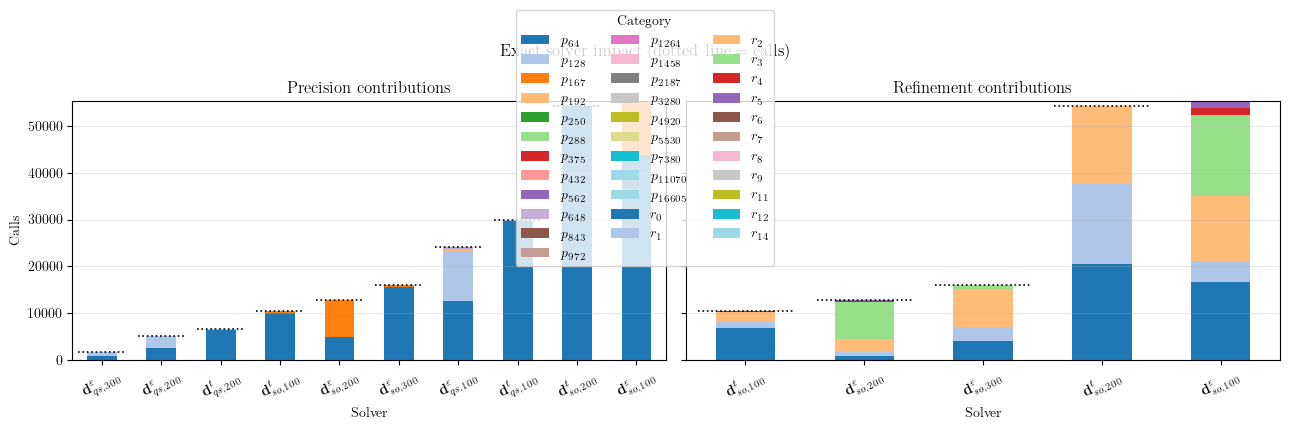

## Exact solver impact

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Calls | $p_{64}$ | $p_{128}$ | $p_{167}$ | $p_{192}$ | $p_{250}$ | $p_{288}$ | $p_{375}$ | $p_{432}$ | $p_{562}$ | $p_{648}$ | $p_{843}$ | $p_{972}$ | $p_{1264}$ | $p_{1458}$ | $p_{2187}$ | $p_{3280}$ | $p_{4920}$ | $p_{5530}$ | $p_{7380}$ | $p_{11070}$ | $p_{16605}$ | $r_{0}$ | $r_{1}$ | $r_{2}$ | $r_{3}$ | $r_{4}$ | $r_{5}$ | $r_{6}$ | $r_{7}$ | $r_{8}$ | $r_{9}$ | $r_{11}$ | $r_{12}$ | $r_{14}$ |
| ------ | ----- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| $ \textbf{d}_{so,100}^\varepsilon $ | 55234 | 43747 | | 11392 | | 42 | | 14 | | 5 | | 6 | | 28 | | | | | | | | | 16569 | 4521 | 13962 | 17370 | 1517 | 1104 | 71 | 66 | 51 | 2 | 1 | | |
| $ \textbf{d}_{so,100}^t $ | 10467 | 10105 | | 357 | | 5 | | | | | | | | | | | | | | | | | 6800 | 1407 | 1980 | 113 | 89 | 61 | 2 | 9 | 4 | 1 | | 1 | |
| $ \textbf{d}_{so,200}^\varepsilon $ | 12835 | 4996 | | 7735 | | 32 | | 23 | | 14 | | 8 | | 27 | | | | | | | | | 893 | 753 | 2904 | 7773 | 181 | 290 | 26 | 6 | 5 | | | | 4 |
| $ \textbf{d}_{so,200}^t $ | 54240 | 54229 | | 11 | | | | | | | | | | | | | | | | | | | 20440 | 17235 | 16557 | 4 | 3 | 1 | | | | | | | |
| $ \textbf{d}_{so,300}^\varepsilon $ | 16038 | 15489 | | 480 | | 36 | | 7 | | 7 | | 4 | | 15 | | | | | | | | | 4077 | 3074 | 8067 | 752 | 43 | 20 | 3 | 2 | | | | | |
| $ \textbf{d}_{qs,100}^\varepsilon $ | 24104 | 12650 | 10736 | | 151 | | 88 | | 35 | | 361 | | 6 | | 2 | 1 | 1 | 2 | 1 | 2 | 1 | 67 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,100}^t $ | 29877 | 29635 | 238 | | 2 | | 2 | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^\varepsilon $ | 5191 | 2565 | 2508 | | 33 | | 23 | | 10 | | 47 | | 2 | | | | | | | | | 3 | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,200}^t $ | 6605 | 6377 | 228 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{d}_{qs,300}^\varepsilon $ | 1675 | 912 | 705 | | 13 | | 8 | | 5 | | 28 | | 1 | | | | | | | | | 3 | | | | | | | | | | | | | |
| $ \textbf{g}_{100} $ | 404675 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |
| $ \textbf{g}_{200} $ | 106046 | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | | |


In [25]:
def exact_solver_impact(solvers_analysis: list[SolverResult]):
    # Instance difficulty categorization
    text = f"""## Exact solver impact

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Calls |"""
    precisions = set()
    refinements = set()

    solvers_analysis = [(solver.solver_name, solver.dataframe[solver.dataframe[f"result{solver.solver_id}"].isin(["sat", "unsat"])], solver.solver_id) for solver in solvers_analysis if "theory::arith::z::arith::relax::calls" in solver.dataframe.columns]

    data = {}

    for solver_name, df, solver_id in solvers_analysis:
        assert "theory::arith::z::arith::relax::calls" in df.columns
        assert df[f"result{solver_id}"].isin(["sat", "unsat"]).all()
        for col in df.columns:
            if col.startswith("precision_") and df[col].sum() > 0:
                precisions.add(col[len("precision_"):])
        for col in df.columns:
            if col.startswith("refinements_") and df[col].sum() > 0:
                refinements.add(col[len("refinements_"):])

    precisions = sorted(precisions, key=lambda x: int(x))
    refinements = sorted(refinements, key=lambda x: int(x))

    for precision in precisions:
        text += f" $p_{{{precision}}}$ |"
    for refinement in refinements:
        text += f" $r_{{{refinement}}}$ |"

    text += "\n| ------ | ----- |"

    for precision in precisions:
        text += f" {'-' * 3} |"
    for refinement in refinements:
        text += f" {'-' * 3} |"

    text += "\n"

    for solver_name, df, solver_id in solvers_analysis:

        calls = int(df["theory::arith::z::arith::relax::calls"].sum())

        # Consistency checks requested: present precision/refinement counters should sum to calls.
        precision_cols = [c for c in df.columns if c.startswith("precision_")]
        refinement_cols = [c for c in df.columns if c.startswith("refinements_")]

        if precision_cols:
            precision_sum = int(df[precision_cols].sum().sum())
            assert precision_sum == calls, (
                f"Precision totals do not match calls for {solver_name}: "
                f"precision_sum={precision_sum}, calls={calls}"
            )
        if refinement_cols:
            refinement_sum = int(df[refinement_cols].sum().sum())
            assert refinement_sum == calls, (
                f"Refinement totals do not match calls for {solver_name}: "
                f"refinement_sum={refinement_sum}, calls={calls}"
            )

        row = f"| {solver_name} | {calls} |"
        for precision in precisions:
            if f"precision_{precision}" in df.columns:
                row += f" {int(df[f'precision_{precision}'].sum())} |"
            else:
                row += " |"
        for refinement in refinements:
            if f"refinements_{refinement}" in df.columns:
                row += f" {int(df[f'refinements_{refinement}'].sum())} |"
            else:
                row += " |"
        data[solver_name] = {
            r"\# Calls": calls,
                **{f"$p_{{{precision}}}$": int(df[f"precision_{precision}"].sum()) for precision in precisions if f"precision_{precision}" in df.columns},
                **{f"$r_{{{refinement}}}$": int(df[f"refinements_{refinement}"].sum()) for refinement in refinements if f"refinements_{refinement}" in df.columns},
        }
        text += row + "\n"

    df = pd.DataFrame(data).T
    for col in df.columns:
        df[col] = df[col].fillna(0).astype(int)

    # Keep a numeric copy for plotting before turning empty values into strings for LaTeX aesthetics.
    plot_df = df.copy()

    df_for_latex = df.copy()
    for col in df_for_latex.columns:
        df_for_latex[col] = df_for_latex[col].apply(lambda x: f"{x}" if x > 0 else "")

    df_for_latex[[r"\# Calls"] + [f"$p_{{{precision}}}$" for precision in precisions] + [f"$r_{{{refinement}}}$" for refinement in refinements]].T.to_latex(
        f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/summary_exact_solver_impact.tex",
        float_format="%.2f",
    )

    # Plot precision/refinement contributions and compare against calls with dotted markers.
    precision_plot_cols = [f"$p_{{{precision}}}$" for precision in precisions]
    refinement_plot_cols = [f"$r_{{{refinement}}}$" for refinement in refinements]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)

    # Precision subplot.
    ax_p = axes[0]
    if precision_plot_cols:
        precision_df = plot_df[[r"\# Calls"] + precision_plot_cols].sort_values(by=r"\# Calls")
        # Show only bars with non-zero precision contribution.
        precision_df = precision_df[precision_df[precision_plot_cols].sum(axis=1) > 0]
        if len(precision_df) > 0:
            precision_df[precision_plot_cols].plot(
                kind="bar",
                stacked=True,
                colormap="tab20",
                ax=ax_p,
                legend=False,
            )
            bar_width = 0.8
            for i, calls in enumerate(precision_df[r"\# Calls"].astype(float).to_numpy()):
                ax_p.hlines(
                    y=calls,
                    xmin=i - bar_width / 2,
                    xmax=i + bar_width / 2,
                    colors="black",
                    linestyles="dotted",
                    linewidth=1.2,
                    zorder=5,
                )
        else:
            ax_p.text(0.5, 0.5, "No non-zero precision bars", ha="center", va="center", transform=ax_p.transAxes)
            ax_p.set_xticks([])
    else:
        ax_p.text(0.5, 0.5, "No precision columns", ha="center", va="center", transform=ax_p.transAxes)
        ax_p.set_xticks([])

    ax_p.set_title("Precision contributions")
    ax_p.set_xlabel("Solver")
    ax_p.set_ylabel("Calls")
    ax_p.grid(axis="y", alpha=0.3)
    ax_p.tick_params(axis="x", labelrotation=25)

    # Refinement subplot.
    ax_r = axes[1]
    if refinement_plot_cols:
        refinement_df = plot_df[[r"\# Calls"] + refinement_plot_cols].sort_values(by=r"\# Calls")
        # Show only bars with non-zero refinement contribution.
        refinement_df = refinement_df[refinement_df[refinement_plot_cols].sum(axis=1) > 0]
        if len(refinement_df) > 0:
            refinement_df[refinement_plot_cols].plot(
                kind="bar",
                stacked=True,
                colormap="tab20",
                ax=ax_r,
                legend=False,
            )
            bar_width = 0.8
            for i, calls in enumerate(refinement_df[r"\# Calls"].astype(float).to_numpy()):
                ax_r.hlines(
                    y=calls,
                    xmin=i - bar_width / 2,
                    xmax=i + bar_width / 2,
                    colors="black",
                    linestyles="dotted",
                    linewidth=1.2,
                    zorder=5,
                )
        else:
            ax_r.text(0.5, 0.5, "No non-zero refinement bars", ha="center", va="center", transform=ax_r.transAxes)
            ax_r.set_xticks([])
    else:
        ax_r.text(0.5, 0.5, "No refinement columns", ha="center", va="center", transform=ax_r.transAxes)
        ax_r.set_xticks([])

    ax_r.set_title("Refinement contributions")
    ax_r.set_xlabel("Solver")
    ax_r.grid(axis="y", alpha=0.3)
    ax_r.tick_params(axis="x", labelrotation=25)

    # Build a combined legend once.
    handles, labels = [], []
    for ax in axes:
        h, l = ax.get_legend_handles_labels()
        handles.extend(h)
        labels.extend(l)
    if handles:
        by_label = dict(zip(labels, handles))
        fig.legend(by_label.values(), by_label.keys(), title="Category", ncols=3, loc="upper center", bbox_to_anchor=(0.5, 1.08))

    fig.suptitle("Exact solver impact (dotted line = calls)")
    plt.tight_layout()
    plt.show()

    return md(text)


exact_solver_impact(
    solvers_analysis=(results | {key: others_results[key] for key in others_results if others_results[key].solver_id == "G"}).values()
)

---

## Section 4: Time Distribution and Instance Difficulty Analysis

### 4.1 Performance Profile Analysis

The following performance profiles help visualize how well each solver variant performs across the entire benchmark set.

In [26]:
def print_difficulty_analysis(
    solvers_analysis: list[SolverResult], total_count: int, group_name = "all"
):
    # Instance difficulty categorization
    text = f"""## Difficulty analysis on {group_name}

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
"""

    # Categorize instances by time range
    def categorize_time(time_val):
        if time_val < 0.1:
            return "Very Fast (<0.1s)"
        elif time_val < 1:
            return "Fast (0.1-1s)"
        elif time_val < 10:
            return "Medium (1-10s)"
        elif time_val < 100:
            return "Hard (10-100s)"
        else:
            return "Very Hard (>100s)"

    # Analyze institution distribution for each solver

    rows = []
    data = {}

    categories = ["Very Fast (<0.1s)", "Fast (0.1-1s)", "Medium (1-10s)", "Hard (10-100s)", "Very Hard (>100s)"]
    latex_categories = ["$[0, 0.1)$s", "$[0.1, 1)$s", "$[1, 10)$s", "$[10, 100)$s", r"$[100, \infty)$s"]
    for solver in solvers_analysis:
        solver_name = solver.solver_name
        df = solver.dataframe
        solver_id = solver.solver_id
        df_copy = (
            df.copy()
            if "theory::arith::z::arith::relax::calls" not in df.columns
            else df[df["theory::arith::z::arith::relax::calls"] > 0].copy()
        )
        df_copy = df_copy[df_copy[f"result{solver_id}"].isin(["sat", "unsat"])]

        df_copy["category"] = df_copy[f"time{solver_id}"].apply(categorize_time)
        assert (
            len(df_copy["options::pivots"].unique()) == 1 if "options::pivots" in df_copy.columns else True
        ), f"Expected only one pivot limit per solver in the analysis, but got {df_copy['options::pivots'].unique()} on solver {solver_name}"
        pivot_limit = int(df_copy["options::pivots"].iloc[0]) if "options::pivots" in df_copy.columns else 0

        row = f"| {solver_name} | {'✔' if "options::strict" in df_copy.columns and  df_copy['options::strict'].iloc[0] else ''} | {pivot_limit}"

        data[solver_name] = {
            r"\# Sol. / \# Tot.": f"{len(df_copy)} / {total_count} ({100 * len(df_copy) / total_count:.1f}\\%)"
        }
        data[solver_name]["solved"] = len(df_copy)
        data[solver_name]["total"] = total_count

        for category, latex_category in zip(categories, latex_categories):
            count = (df_copy["category"] == category).sum()
            if count > 0:
                pct = 100 * count / len(df_copy)
                row += f" | {count} ({pct:.1f}%)"
                data[solver_name][latex_category] = int(count)
            else:
                row += " | 0"
        row += f" | {len(df_copy)} / {total_count} ({100 * len(df_copy) / total_count:.1f}%)"
        rows.append(row)

    data_df = pd.DataFrame(data).T
    for col in data_df.columns:
        if col != r"\# Sol. / \# Tot.":
            data_df[col] = data_df[col].fillna(0).astype(int)
    data_df.sort_values(by=["solved"] + latex_categories, inplace=True, ascending=False)
    data_df.drop(columns=["solved", "total"]).to_latex(
        f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/difficulty_analysis_{group_name.lower().replace(' ', '_')}.tex",
        float_format="%.2f",
    )

    ax = data_df[latex_categories] .plot(
        kind="bar",
        stacked=True,
        colormap="tab20",
    )
    ax.set_ylabel("Solved instances")
    ax.grid(axis="y", alpha=0.3)
    plt.xticks(rotation=25, ha="center")
    plt.tight_layout()
    box = ax.get_position()
    ax.set_position([box.x0, box.y0, box.width * 0.8, box.height * 0.8])

    # Put a legend to the right of the current axis
    ax.legend(title="Category", loc='center left', bbox_to_anchor=(1, 0.5))
    plt.show()

    ax.figure.savefig(f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/difficulty_analysis_{group_name.lower().replace(' ', '_')}.pgf", bbox_inches="tight")

    return md(
        f"""{text}{"\n".join(rows)}
"""
    )

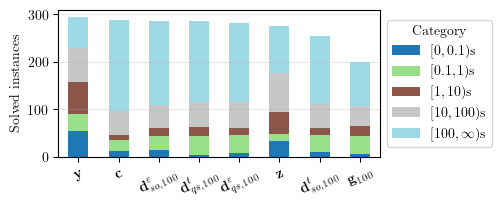

## Difficulty analysis on 100

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 55 (18.6%) | 35 (11.9%) | 68 (23.1%) | 72 (24.4%) | 65 (22.0%) | 295 / 319 (92.5%)
| $ \textbf{z} $ |  | 0 | 34 (12.3%) | 14 (5.1%) | 46 (16.7%) | 83 (30.1%) | 99 (35.9%) | 276 / 319 (86.5%)
| $ \textbf{c} $ |  | 0 | 12 (4.2%) | 24 (8.3%) | 10 (3.5%) | 50 (17.3%) | 193 (66.8%) | 289 / 319 (90.6%)
| $ \textbf{g}_{100} $ |  | 100 | 6 (3.0%) | 38 (19.1%) | 22 (11.1%) | 41 (20.6%) | 92 (46.2%) | 199 / 319 (62.4%)
| $ \textbf{d}_{so,100}^\varepsilon $ |  | 100 | 14 (4.9%) | 30 (10.5%) | 16 (5.6%) | 50 (17.4%) | 177 (61.7%) | 287 / 319 (90.0%)
| $ \textbf{d}_{so,100}^t $ | ✔ | 100 | 11 (4.3%) | 34 (13.4%) | 15 (5.9%) | 52 (20.5%) | 142 (55.9%) | 254 / 319 (79.6%)
| $ \textbf{d}_{qs,100}^\varepsilon $ |  | 100 | 8 (2.8%) | 37 (13.2%) | 16 (5.7%) | 54 (19.2%) | 166 (59.1%) | 281 / 319 (88.1%)
| $ \textbf{d}_{qs,100}^t $ | ✔ | 100 | 4 (1.4%) | 40 (13.9%) | 18 (6.3%) | 54 (18.8%) | 171 (59.6%) | 287 / 319 (90.0%)


In [27]:
print_difficulty_analysis(
    solvers_analysis=[
        others_results["yices"].apply_filter(in_100),
        others_results["z3"].apply_filter(in_100),
        others_results["cvc5"].apply_filter(in_100),
        others_results["glpk_i100"],
        results["soplex_i100"],
        results["soplex_i100_strict"],
        results["qsoptex_i100"],
        results["qsoptex_i100_strict"],
    ],
    total_count= len(instances_100),
    group_name="100",
)

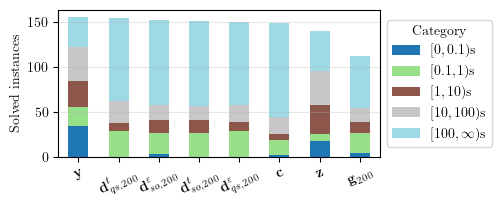

## Difficulty analysis on 200

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 34 (21.8%) | 22 (14.1%) | 28 (17.9%) | 38 (24.4%) | 34 (21.8%) | 156 / 177 (88.1%)
| $ \textbf{z} $ |  | 0 | 18 (12.9%) | 7 (5.0%) | 33 (23.6%) | 38 (27.1%) | 44 (31.4%) | 140 / 177 (79.1%)
| $ \textbf{c} $ |  | 0 | 2 (1.3%) | 17 (11.4%) | 6 (4.0%) | 19 (12.8%) | 105 (70.5%) | 149 / 177 (84.2%)
| $ \textbf{g}_{200} $ |  | 200 | 4 (3.6%) | 22 (19.6%) | 13 (11.6%) | 15 (13.4%) | 58 (51.8%) | 112 / 177 (63.3%)
| $ \textbf{d}_{so,200}^\varepsilon $ |  | 200 | 3 (2.0%) | 24 (15.7%) | 14 (9.2%) | 17 (11.1%) | 95 (62.1%) | 153 / 177 (86.4%)
| $ \textbf{d}_{so,200}^t $ | ✔ | 200 | 0 | 27 (17.9%) | 14 (9.3%) | 16 (10.6%) | 94 (62.3%) | 151 / 177 (85.3%)
| $ \textbf{d}_{qs,200}^\varepsilon $ |  | 200 | 0 | 29 (19.3%) | 10 (6.7%) | 19 (12.7%) | 92 (61.3%) | 150 / 177 (84.7%)
| $ \textbf{d}_{qs,200}^t $ | ✔ | 200 | 0 | 29 (18.7%) | 9 (5.8%) | 24 (15.5%) | 93 (60.0%) | 155 / 177 (87.6%)


In [28]:
print_difficulty_analysis(
    solvers_analysis=[
        others_results["yices"].apply_filter(in_200),
        others_results["z3"].apply_filter(in_200),
        others_results["cvc5"].apply_filter(in_200),
        others_results["glpk_i200"],
        results["soplex_i200"],
        results["soplex_i200_strict"],
        results["qsoptex_i200"],
        results["qsoptex_i200_strict"],
    ],
   total_count= len(instances_200),
   group_name="200",
)

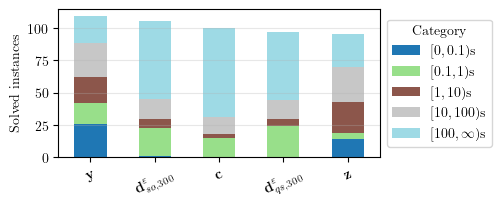

## Difficulty analysis on 300

Difficulty analysis on instances with external simplex calls (except for baseline cvc5, which is included for reference but does not make external simplex calls)

| Solver | Strict | Pivots | Very Fast (<0.1s) | Fast (0.1-1s) | Medium (1-10s) | Hard (10-100s) | Very Hard (>100s) | Total |
| ------ | ------ | ------ | ----------------- | ------------- | -------------- | -------------- | ----------------- | ----- |
| $ \textbf{y} $ |  | 0 | 26 (23.9%) | 16 (14.7%) | 20 (18.3%) | 26 (23.9%) | 21 (19.3%) | 109 / 125 (87.2%)
| $ \textbf{z} $ |  | 0 | 14 (14.7%) | 5 (5.3%) | 24 (25.3%) | 27 (28.4%) | 25 (26.3%) | 95 / 125 (76.0%)
| $ \textbf{c} $ |  | 0 | 0 | 15 (15.0%) | 3 (3.0%) | 13 (13.0%) | 69 (69.0%) | 100 / 125 (80.0%)
| $ \textbf{d}_{so,300}^\varepsilon $ |  | 300 | 1 (1.0%) | 22 (21.0%) | 7 (6.7%) | 15 (14.3%) | 60 (57.1%) | 105 / 125 (84.0%)
| $ \textbf{d}_{qs,300}^\varepsilon $ |  | 300 | 0 | 24 (24.7%) | 6 (6.2%) | 14 (14.4%) | 53 (54.6%) | 97 / 125 (77.6%)


In [29]:
print_difficulty_analysis(
    solvers_analysis=[
        others_results["yices"].apply_filter(in_300),
        others_results["z3"].apply_filter(in_300),
        others_results["cvc5"].apply_filter(in_300),
        # others_results["glpk_i300"],
        results["soplex_i300"],
        # results["soplex_i300_strict"],
        results["qsoptex_i300"],
        # results["qsoptex_i300_strict"],
    ],
   total_count= len(instances_300),
   group_name="300",
)

In [30]:
def print_difficulty_analysis_by_group(group: pd.DataFrame, iterations: int, group_name: str = "QF_LRA"):
    if iterations == 100:
        instances_filter = instances_100
        return print_difficulty_analysis(
            solvers_analysis=[
                others_results["yices"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["z3"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["cvc5"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["glpk_i100"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i100"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i100_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i100"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i100_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=group_name
        )
    elif iterations == 200:
        instances_filter = instances_200
        return print_difficulty_analysis(
            solvers_analysis=[
                others_results["yices"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["z3"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["cvc5"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                others_results["glpk_i200"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i200"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["soplex_i200_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i200"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
                results["qsoptex_i200_strict"].apply_filter(lambda df: in_instances(df, group, instances_filter)),
             ],
            total_count=len(pd.merge(group, instances_filter, on="file", how="inner")),
            group_name=group_name
        )

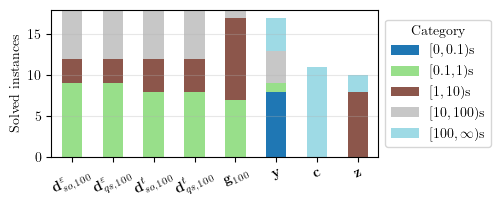

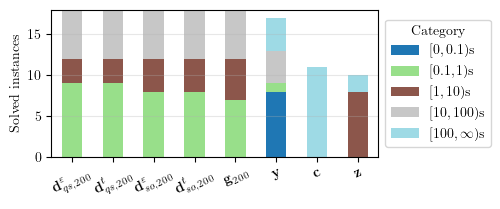

(<IPython.core.display.Markdown object>,
 <IPython.core.display.Markdown object>)

In [31]:
print_difficulty_analysis_by_group(lanteresse, 100, "Lanteresse"), print_difficulty_analysis_by_group(lanteresse, 200, "Lanteresse"),

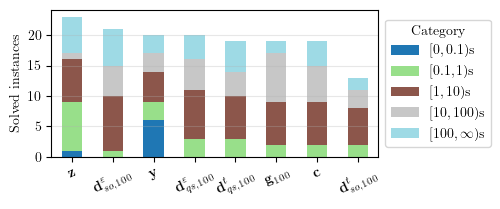

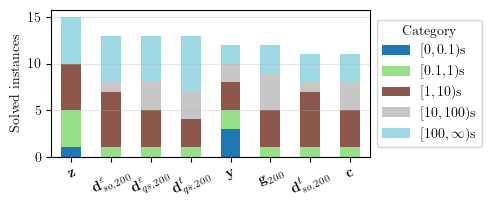

(<IPython.core.display.Markdown object>,
 <IPython.core.display.Markdown object>)

In [32]:
print_difficulty_analysis_by_group(mplib, 100, "MPLIB"), print_difficulty_analysis_by_group(mplib, 200, "MPLIB")


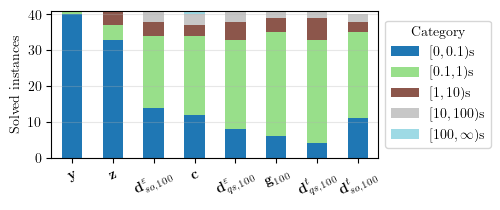

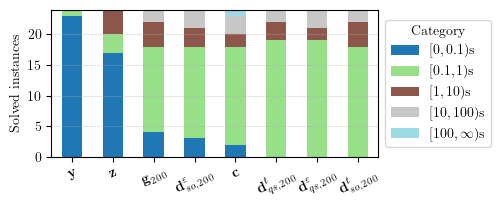

(<IPython.core.display.Markdown object>,
 <IPython.core.display.Markdown object>)

In [33]:
print_difficulty_analysis_by_group(dtp_scheduling, 100, "DTP Scheduling"), print_difficulty_analysis_by_group(dtp_scheduling, 200, "DTP Scheduling"),

In [34]:
def to_new_solver_id(solver_result: SolverResult):
    return f"{solver_result.solver_id}{solver_result.iterations}{'S' if '^t' in solver_result.solver_name.lower() else ''}{'D' if r'\delta' in solver_result.solver_name.lower() else ''}"

cvc5_variants_results = [
    SolverResult(
        dataframe=solver_result.dataframe.reset_index()[
            ["file", f"time{solver_result.solver_id}", f"result{solver_result.solver_id}", *(["options::pivots"] if "options::pivots" in solver_result.dataframe.columns else [])]
        ]
        .rename(
            columns={
                f"time{solver_result.solver_id}": f"time{to_new_solver_id(solver_result)}",
                f"result{solver_result.solver_id}": f"result{to_new_solver_id(solver_result)}",
            }
        )
        .set_index("file"),
        solver_name=solver_result.solver_name,
        solver_id=to_new_solver_id(solver_result),
        iterations=solver_result.iterations,
    )
    for solver_result in (results | others_results).values()
    if solver_result.solver_id in ["C", "S", "Q", "G"]
]

other_profile_results = [
    SolverResult(
        dataframe=solver_result.dataframe.reset_index()[
            ["file", f"time{solver_result.solver_id}", f"result{solver_result.solver_id}"]
        ]
        .rename(
            columns={
                f"time{solver_result.solver_id}": f"time{to_new_solver_id(solver_result)}",
                f"result{solver_result.solver_id}": f"result{to_new_solver_id(solver_result)}",
            }
        )
        .set_index("file"),
        solver_name=solver_result.solver_name,
        solver_id=to_new_solver_id(solver_result),
        iterations=solver_result.iterations,
    )
    for solver_result in others_results.values()
    if solver_result.solver_id in ["Y", "Z"]
]

# Get the set of instances where any of the SoPlex variants makes external simplex calls, and filter all profiles to only those instances
external_instances_100 = list(instances_100_list)
external_instances_200 = list(instances_200_list)
external_instances_300 = list(instances_300_list)

external_cvc5_variants_results: dict[int, list[SolverResult]] = {}
external_profile_results: dict[int, list[SolverResult]] = {}
for iteration in ITERATIONS:
        external_cvc5_variants_results[iteration] = [
            result.replace_df(in_n(result.dataframe.drop(columns=["options::pivots"], errors="ignore"), iteration))
            for result in cvc5_variants_results
            if "options::pivots" not in result.dataframe.columns or result.dataframe["options::pivots"].iloc[0] == iteration
        ]
        external_profile_results[iteration] = external_cvc5_variants_results[iteration] + [
            result.replace_df(in_n(result.dataframe, iteration)) for result in other_profile_results
        ]

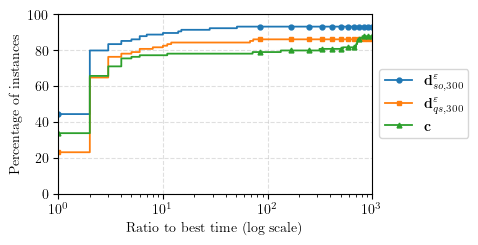

In [35]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants_results[300],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    num_points=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_300_cvc5.pgf", dpi=300)

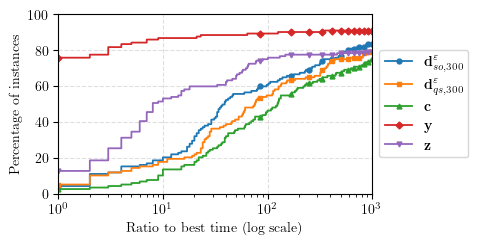

In [36]:
ax, fig = plot_performance_profiles(
    *external_profile_results[300],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
    num_points=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_all.pgf", dpi=300)

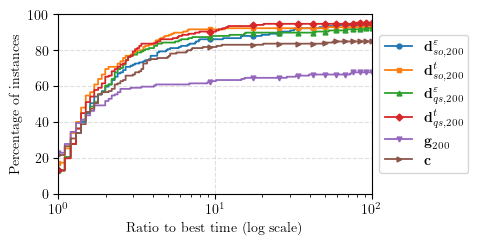

In [37]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants_results[200],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=100,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_cvc5.pgf", dpi=300)

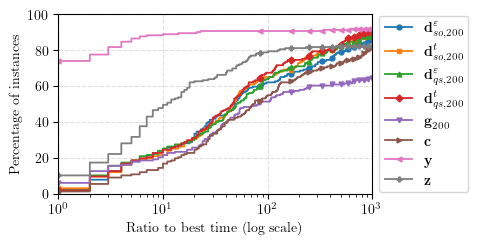

In [38]:
ax, fig = plot_performance_profiles(
    *external_profile_results[200],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_200_all.pgf", dpi=300)

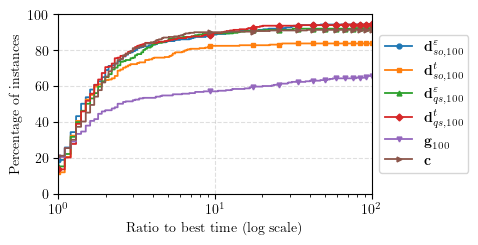

In [39]:
ax, fig = plot_performance_profiles(
    *external_cvc5_variants_results[100],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=100,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_100_cvc5.pgf", dpi=300)

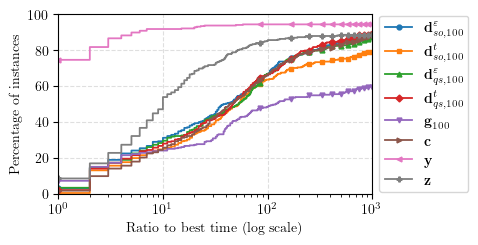

In [40]:
ax, fig = plot_performance_profiles(
    *external_profile_results[100],
    accepted_results=["sat", "unsat"],
    result_cols="result",
    metric_cols="time",
    max_tau=1000,
)
ax.figure.savefig("/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/img/pp_100_all.pgf", dpi=300)

In [41]:
column_map = {
    "timeY-1": r"$\textbf{y}$",
    "timeZ-1": r"$\textbf{z}$",
    "timeC-1": r"$\textbf{c}$",
    "timeG100": r"$\textbf{g}_{100}$",
    "timeG200": r"$\textbf{g}_{200}$",
    "timeG300": r"$\textbf{g}_{300}$",
    "timeS100": r"$\textbf{d}_{so,100}^\varepsilon$",
    "timeS100S": r"$\textbf{d}_{so,100}^t$",
    "timeS200": r"$\textbf{d}_{so,200}^\varepsilon$",
    "timeS200S": r"$\textbf{d}_{so,200}^t$",
    "timeS300": r"$\textbf{d}_{so,300}^\varepsilon$",
    "timeS300S": r"$\textbf{d}_{so,300}^t$",
    "timeQ100": r"$\textbf{d}_{qs,100}^\varepsilon$",
    "timeQ100S": r"$\textbf{d}_{qs,100S}^t$",
    "timeQ200": r"$\textbf{d}_{qs,200}^\varepsilon$",
    "timeQ200S": r"$\textbf{d}_{qs,200}^t$",
    "timeQ300": r"$\textbf{d}_{qs,300}^\varepsilon$",
    "timeQ300S": r"$\textbf{d}_{qs,300}^t$",
}

In [42]:
for iteration in ITERATIONS:
    df_all = reduce(
        lambda left, right: pd.merge(left, right, left_index=True, right_index=True, how="outer"), (result.dataframe for result in external_profile_results[iteration])
    )
    df_all_column_map = {col: name for col, name in column_map.items() if col in df_all.columns}
    df_all["Problem"] = df_all.index
    df_all["Problem"] = df_all["Problem"].apply(lambda x: x.replace(".smt2", "")[:30])
    df_all[["Problem"] + list(df_all_column_map.keys())].rename(columns=df_all_column_map).to_latex(
        f"/home/campus.ncl.ac.uk/c3054737/Programming/phd/dlinear-paper/tables/all_times_{iteration}.tex",
        float_format="%.1f",
        longtable=True,
        index=False,
        na_rep="-",
    )

In [43]:
df = results["soplex_i100_strict"].dataframe
df[df["theory::arith::z::arith::relax::infeasible::failures"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
ecoliMILPglycerolYices3-50000.smt2,20856,39,570,1767,0,1,123


In [44]:
df[df["theory::arith::z::arith::relax::feasible::failures"] > 0][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
vpm2-10.smt2,23028,20,64,80,4,0,417
danoint-266.smt2,163659,533,5385,19033,7,0,842
_standard_strcmp_ground.i_4_2_2.bpl_11.smt2,252680,10,279,227,1,0,101
_simple4.i_3_4_2.bpl_11.smt2,529499,134,427,2173,1,0,80
danoint-166.smt2,562820,2079,20634,95633,8,0,964
_const1.i_3_6_2.bpl_11.smt2,1556729,61,214,333,1,0,54
yPositive-SIscaled100.bpl_Iteration1_Loop_6-phaseTemplate.smt2,1574032,86,50482,42985,1,0,120
constraint-223827.smt2,3804733,343,4035,3707,4,0,480
hongyi1.t2.c_Iteration1_Loop_4-pieceTemplate.smt2,10284442,177,175909,121768,5,0,600


In [45]:
df[(df["theory::arith::z::approx::externalAdjustmentPivots"] > 0) & (df["theory::arith::z::arith::relax::feasible::failures"] == 0) & (df["theory::arith::z::arith::relax::infeasible::failures"] == 0)][INTERESTING_COLS].sort_values("global::totalTime")

,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,
constraints-tms-2-3-light-20.smt2,120,1,1,1,0,0,1
constraints-tms-2-3-light-60.smt2,203,2,8,8,0,0,1
constraints-tms-2-3-light-70.smt2,238,2,10,8,0,0,2
constraints-tms-2-3-light-80.smt2,284,2,12,9,0,0,2
constraints-tms-2-3-light-90.smt2,333,2,12,11,0,0,3
vpm2-5.smt2,1343,6,20,28,0,0,3
vpm2-30.smt2,3173,7,24,37,0,0,2
clocksynchro_6clocks.main_invar.induct.smt2,9992,5,20,52,0,0,8
clocksynchro_9clocks.worst_case_skew.induct.smt2,13907,1,2,8,0,0,1


In [46]:
df[df["theory::arith::z::arith::relax::other"] > 0][INTERESTING_COLS].sort_values("global::totalTime")


,global::totalTime,theory::arith::z::arith::relax::calls,theory::arith::z::approx::lp::setup::timer,theory::arith::z::approx::lp::timer,theory::arith::z::arith::relax::feasible::failures,theory::arith::z::arith::relax::infeasible::failures,theory::arith::z::approx::externalAdjustmentPivots
file,,,,,,,


In [47]:
# compare_df = pd.merge(results["qsoptex_i100_delta1e-08"].dataframe, others_results["yices"].dataframe, left_index=True, right_index=True)
# compare_df[compare_df["resultQ"] != compare_df["resultY"]]
# compare_df